## 📝 Instrucciones ##


**Predecir el coste del seguro médico de una persona**

La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de los datos fisiológicos de sus clientes, **cuál va a ser la prima (coste)** que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.

## Paso 1: Carga del conjunto de datos a tu modelo

In [61]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre medical_insurance_cost.csv. Puedes cargarlo en el código directamente desde el siguente enlace:

https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv
O descargarlo y añadirlo a mano en tu repositorio. En este conjunto de datos encontrarás las siguientes variables:

| Variable | Descripción                                                                 | Tipo        |
|----------|-----------------------------------------------------------------------------|------------|
| age      | Edad del beneficiario principal                                             | Numérico   |
| sex      | Género del beneficiario principal                                           | Categórico |
| bmi      | Índice de masa corporal                                                     | Numérico   |
| children | Número de niños/dependientes cubiertos por el seguro médico                 | Numérico   |
| smoker   | Indica si el beneficiario es fumador                                        | Categórico |
| region   | Área residencial en EE.UU. (noreste, sureste, suroeste, noroeste)           | Categórico |
| charges  | Prima del seguro médico                                                     | Numérico   |

In [26]:
df = pd.read_csv('../data/raw/medical_insurance_cost.csv', delimiter= ',')

## Paso 2: Realiza un EDA completo

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en lecciones anteriores.

In [21]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [7]:
df.shape

(1338, 7)

In [9]:
# Estadística descriptiva
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Análisis visual ##

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

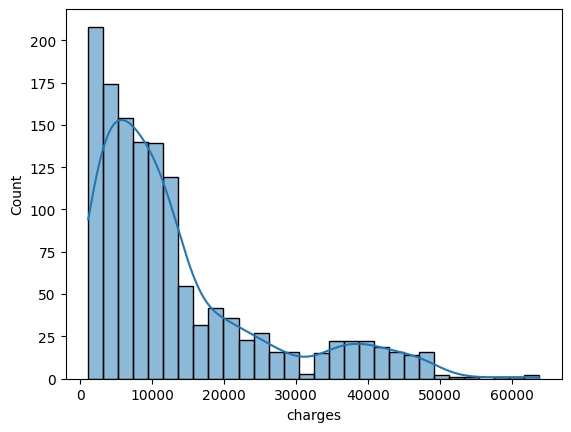

In [27]:
sns.histplot(df['charges'], kde=True)
df['charges'].describe()

<Axes: xlabel='charges_log', ylabel='Count'>

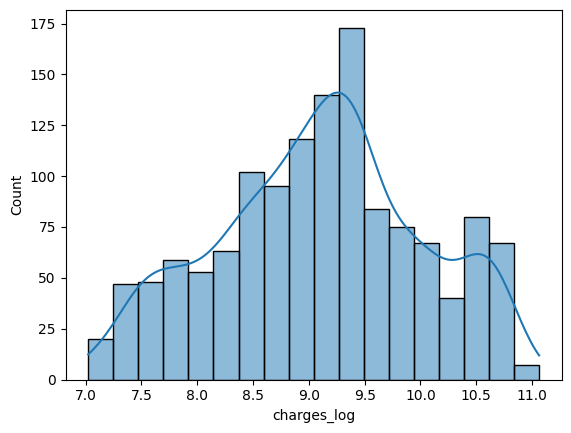

In [28]:
#con datos tan sesgados se aplica transoformación logarítmica
df['charges_log'] = np.log(df['charges'])
sns.histplot(df['charges_log'], kde=True)

In [29]:
#sustituimos la variable charges por su logaritmo
df['charges'] = df['charges_log']
df.drop(columns=['charges'], inplace=True)

df.describe()

,age,bmi,children,charges_log
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,9.098659
std,14.049960,6.098187,1.205493,0.919527
min,18.000000,15.960000,0.000000,7.022756
25%,27.000000,26.296250,0.000000,8.463853
50%,39.000000,30.400000,1.000000,9.146552
75%,51.000000,34.693750,2.000000,9.719558
max,64.000000,53.130000,5.000000,11.063045


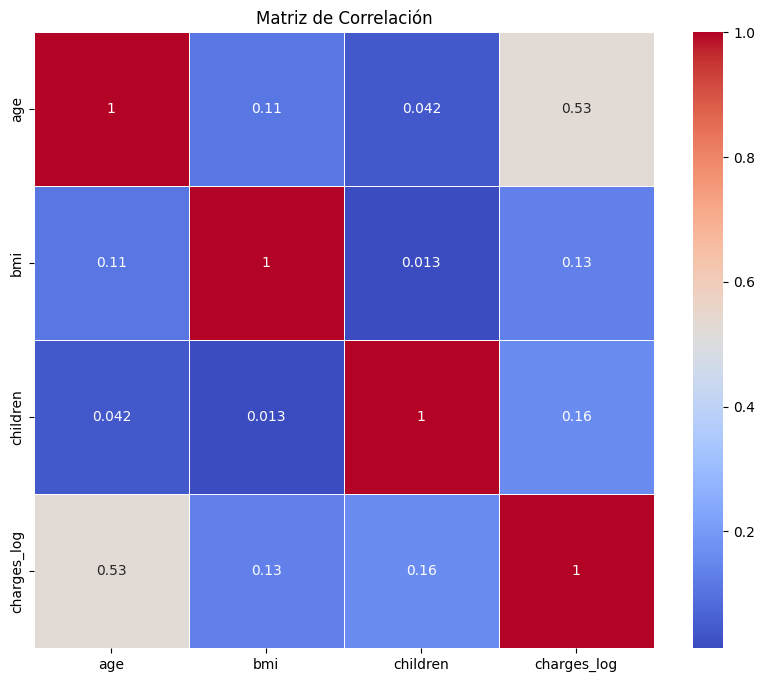

In [40]:
#matriz decorrelación para ver que variables podrían explicar el coste
df.corr(numeric_only=True)['charges_log'].sort_values(ascending=False)
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
plt.title('Matriz de Correlación')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()




**La edad es la variable numérica con mayor relevancia. Ahora analizamos categóricas**

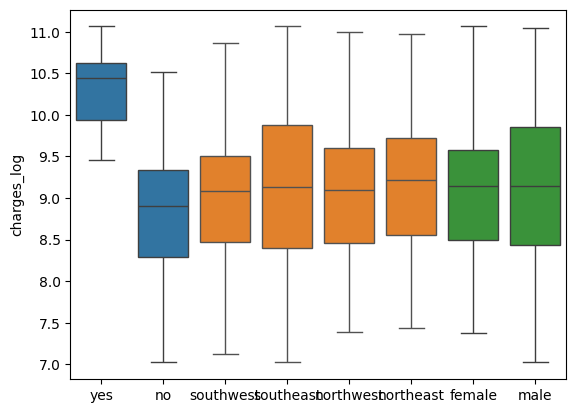

In [ ]:
sns.boxplot(x='smoker', y='charges_log', data=df)
sns.boxplot(x='region', y='charges_log', data=df)
sns.boxplot(x='sex', y='charges_log', data=df)
plt.xlabel('')
plt.show()

**Evidentemente la variable fumador es la que más peso tiene. Ya podemos pasar a preparar el modelo...** 

## Paso 3: Construye un modelo de regresión
Comienza a resolver el problema implementando un modelo de regresión lineal y analiza los resultados. A continuación, utilizando los mismos datos y los atributos por defecto, construye un modelo Lasso y compara los resultados con la regresión lineal base.

Analiza cómo evoluciona el R2 cuando el hiperparámetro del modelo Lasso cambia (puedes por ejemplo empezar a probar desde el valor 0.0 e ir aumentándolo hasta un valor de 20). Dibuja estos valores en un diagrama de líneas.

In [51]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,bmi,children,charges_log,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,9.734176,False,True,False,False,True
1,18,33.770,1,7.453302,True,False,False,True,False
2,28,33.000,3,8.400538,True,False,False,True,False
3,33,22.705,0,9.998092,True,False,True,False,False
4,32,28.880,0,8.260197,True,False,True,False,False


In [56]:
df_encoded.shape

(1338, 9)

In [58]:
#Definimos variables y dividimos modelo
X = df_encoded.drop(columns=['charges_log'])
y = df_encoded['charges_log']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1070, 8), (268, 8), (1070,), (268,))

In [59]:
#entrenamos modelo
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [60]:
#coeficientes del modelo
pd.DataFrame({'variable': X.columns, 'coeficiente': model.coef_}).sort_values(by='coeficiente', ascending=False)

,variable,coeficiente
4,smoker_yes,1.551698
2,children,0.092448
0,age,0.034245
1,bmi,0.013600
5,region_northwest,-0.056414
3,sex_male,-0.074350
7,region_southwest,-0.122557
6,region_southeast,-0.136068


** Ser fumador se confirma como la variable que mejor explica el costo **

*Es importante aclarar que los coeficientes son en términos porcentuales debido a la transformación logarítmica aplicada*

El modelo refleja que la variable más significativa en el costo del seguro es el hábito de fumar. Variables como la edad, el número de hijos y el índice de masa corporal también tienen relación positiva pero con un menor impacto. 

## Paso 4: Optimiza el modelo de regresión anterior
Después de entrenar el modelo Lasso, si los resultados no son satisfactorios, optimízalo empleando alguna de las técnicas vistas anteriormente.

In [62]:
#Evaluación del modelo
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = np.mean(np.abs(y_test - y_pred))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'R²: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')

R²: 0.8047
MAE: 0.2697
MSE: 0.1756
RMSE: 0.4190


**r2 de 0.80 es un valor alto, lo que indica que el modelo tiene buena capacidad de explicar el costo del seguro**

El error medio absoluto explica que las predicciones se desvían 0.27 unidades del valor real. 


Ahora intentemos optimizar...

In [84]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

In [70]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
model = Lasso(alpha=0.1)
model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [87]:
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train_scaled, y_train)

print(f'Mejor alpha: {grid.best_params_["alpha"]}')
print(f'Mejor R²: {grid.best_score_:.4f}')

Mejor alpha: 0.01
Mejor R²: 0.7501


In [88]:
model = Lasso(alpha=0.1, max_iter=10000)
model.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",10000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [89]:
y_pred_lasso = model.predict(X_test_scaled)

print(f'R²: {r2_score(y_test, y_pred_lasso):.4f}')
print(f'MAE: {np.mean(np.abs(y_test - y_pred_lasso)):.4f}')
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.4f}')

R²: 0.7431
MAE: 0.3298
MSE: 0.2310
RMSE: 0.4807


In [90]:
coef = pd.Series(model.coef_, index=X.columns)
print(coef.sort_values(ascending=False))

smoker_yes          0.520218
age                 0.391310
children            0.019162
bmi                 0.000000
sex_male           -0.000000
region_northwest    0.000000
region_southeast   -0.000000
region_southwest   -0.000000
dtype: float64


**Aparentemente la optimización no ha funcionado porque la r2 del modelo bajó de 0.80 a 0.74, sin embargo, es importante considerar que en un modelo de Regresión Linear existe riesgo de sobre ajustar los datos mientras que en el modelo Lasso no, además de que reduce el efecto del ruido.**